<a href="https://colab.research.google.com/github/Savcdilara/MicrosoftStaj/blob/main/RSA%2BAESkeyGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================
# 🔐 AES+RSA Key Generation and Entropy Evaluation
# ====================================================
# Author: Dilara Savcı
# Project: AI-Based Dynamic Key Generation System
# Dataset: CIC-IDS2017
# Method: AES Key Generation (Baseline)
# ====================================================
!pip install pycryptodome
import pandas as pd
import numpy as np
import secrets
import time
import matplotlib.pyplot as plt
from google.colab import drive
import glob
from Crypto.PublicKey import RSA
from Crypto.Cipher import AES, PKCS1_OAEP
from Crypto.Random import get_random_bytes



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 22.5 MB/s eta 0:00:00


In [ ]:
# ====================================================
# 1️⃣ Load Dataset
# ====================================================
drive.mount('/content/drive')

path = "/content/drive/MyDrive/MachineLearningCVE/"
files = glob.glob(path + "*.csv")

df_list = []
for file in files:
    temp = pd.read_csv(file, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Mounted at /content/drive
✅ Dataset loaded successfully
Shape: (2830743, 79)
Columns: 79


In [ ]:
# ====================================================
# 2️⃣ Utility: Entropy and Key/Encryption helpers
# ====================================================
def calculate_entropy(data):
    """Byte histogram üzerinden entropi hesaplar (bits per byte; maks ~8)"""
    if isinstance(data, str):
        data = data.encode()
    if len(data) == 0:
        return 0.0
    byte_counts = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256)
    probs = byte_counts / len(data)
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

def generate_aes_key(key_size=256):
    """AES anahtarı (bytes) üretir"""
    return get_random_bytes(key_size // 8)

def generate_rsa_key(key_size=2048):
    """RSA keypair üretir (Crypto.PublicKey.RSA object)"""
    return RSA.generate(key_size)

def aes_encrypt(plaintext: bytes, key: bytes):
    """AES-EAX ile şifrele, geri döndür: nonce + tag + ciphertext (bütünleyici)"""
    cipher = AES.new(key, AES.MODE_EAX)
    ciphertext, tag = cipher.encrypt_and_digest(plaintext)
    # Döndürülen byte dizisi: nonce | tag | ciphertext
    return cipher.nonce + tag + ciphertext

def rsa_wrap_key(aes_key: bytes, rsa_pubkey):
    """RSA public key ile AES anahtarını sar (wrap) - PKCS1_OAEP"""
    rsa_cipher = PKCS1_OAEP.new(rsa_pubkey)
    return rsa_cipher.encrypt(aes_key)

In [ ]:
# ====================================================
# 3️⃣ Hybrid Generation Params
# ====================================================
num_keys = 200          # RSA üretimi ağır, 200 dengeli bir başlangıç (dilersen artır)
rsa_key_length = 2048   # bits
aes_key_length = 256    # bits
sample_plaintext = b"This is a sample plaintext for hybrid encryption testing."  # aynı veri her seferinde

# Depolama değişkenleri
aes_keys_all = b""
rsa_wrapped_aes_all = b""
aes_ciphertexts_all = b""

aes_key_entropies = []
rsa_wrapped_entropies = []
aes_cipher_entropies = []

times_aes_keygen = []
times_rsa_keygen = []
times_wrap = []
times_aes_encrypt = []

print("\n⏳ Generating hybrid (RSA+AES) keys and encrypting...")

for i in range(num_keys):
    # --- RSA keypair üretimi ---
    t0 = time.time()
    rsa_key = generate_rsa_key(rsa_key_length)
    t1 = time.time()
    times_rsa_keygen.append(t1 - t0)

    rsa_pub = rsa_key.publickey()

    # --- AES anahtarı üretimi ---
    t0 = time.time()
    aes_key = generate_aes_key(aes_key_length)
    t1 = time.time()
    times_aes_keygen.append(t1 - t0)

    # --- AES ile veri şifreleme (örnek veri) ---
    t0 = time.time()
    aes_cipher = aes_encrypt(sample_plaintext, aes_key)
    t1 = time.time()
    times_aes_encrypt.append(t1 - t0)

    # --- RSA public ile AES anahtarını sarmak (wrap) ---
    t0 = time.time()
    wrapped = rsa_wrap_key(aes_key, rsa_pub)
    t1 = time.time()
    times_wrap.append(t1 - t0)

    # --- Entropi ölçümleri (bireysel) ---
    ent_aes_key = calculate_entropy(aes_key)
    ent_wrapped = calculate_entropy(wrapped)
    ent_aes_cipher = calculate_entropy(aes_cipher)

    aes_key_entropies.append(ent_aes_key)
    rsa_wrapped_entropies.append(ent_wrapped)
    aes_cipher_entropies.append(ent_aes_cipher)

    # --- Toplu byte dizilerine ekle (daha istikrarlı combined entropi için) ---
    aes_keys_all += aes_key
    rsa_wrapped_aes_all += wrapped
    aes_ciphertexts_all += aes_cipher

    # (isteğe bağlı) durum yazdır
    if (i+1) % 50 == 0:
        print(f"  - {i+1}/{num_keys} completed")


⏳ Generating hybrid (RSA+AES) keys and encrypting...
  - 50/200 completed
  - 100/200 completed
  - 150/200 completed
  - 200/200 completed


In [ ]:
# ====================================================
# 4️⃣ Combined Entropy (tüm örnekler için)
# ====================================================
combined_entropy_aes_keys = calculate_entropy(aes_keys_all)
combined_entropy_wrapped = calculate_entropy(rsa_wrapped_aes_all)
combined_entropy_aes_cipher = calculate_entropy(aes_ciphertexts_all)

# Ortalama zamanlar (ms)
mean_time_rsa_gen = np.mean(times_rsa_keygen) * 1000
mean_time_aes_gen = np.mean(times_aes_keygen) * 1000
mean_time_wrap = np.mean(times_wrap) * 1000
mean_time_aes_encrypt = np.mean(times_aes_encrypt) * 1000

In [ ]:
# ====================================================
# 5️⃣ Statistical Analysis (Summary)
# ====================================================
print("\n🔎 Hybrid (RSA+AES) Generation Statistics (per-sample averages & combined entropies)")
summary = {
    "Algorithm": "RSA+AES (Hybrid)",
    "RSA Key Length (bits)": rsa_key_length,
    "AES Key Length (bits)": aes_key_length,
    "Number of Samples": num_keys,
    "Combined Entropy (AES keys)": round(combined_entropy_aes_keys, 4),
    "Combined Entropy (RSA-wrapped AES)": round(combined_entropy_wrapped, 4),
    "Combined Entropy (AES ciphertexts)": round(combined_entropy_aes_cipher, 4),
    "Mean Entropy (AES key, per-sample)": round(np.mean(aes_key_entropies), 4),
    "Std Entropy (AES key, per-sample)": round(np.std(aes_key_entropies), 4),
    "Mean Time RSA gen (ms)": round(mean_time_rsa_gen, 4),
    "Mean Time AES gen (ms)": round(mean_time_aes_gen, 6),
    "Mean Time wrap (ms)": round(mean_time_wrap, 4),
    "Mean Time AES encrypt (ms)": round(mean_time_aes_encrypt, 4)
}
results_df = pd.DataFrame([summary])
display(results_df)



🔎 Hybrid (RSA+AES) Generation Statistics (per-sample averages & combined entropies)


,Algorithm,RSA Key Length (bits),AES Key Length (bits),Number of Samples,Combined Entropy (AES keys),Combined Entropy (RSA-wrapped AES),Combined Entropy (AES ciphertexts),"Mean Entropy (AES key, per-sample)","Std Entropy (AES key, per-sample)",Mean Time RSA gen (ms),Mean Time AES gen (ms),Mean Time wrap (ms),Mean Time AES encrypt (ms)
0,RSA+AES (Hybrid),2048,256,200,7.9735,7.9959,7.9898,4.8906,0.0812,581.8954,0.00409,0.7716,0.4357


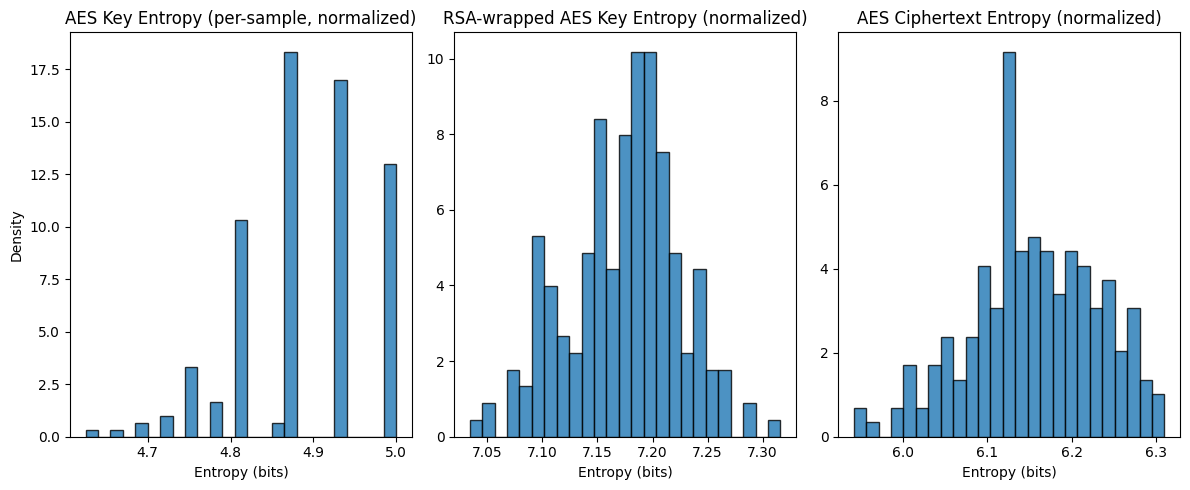

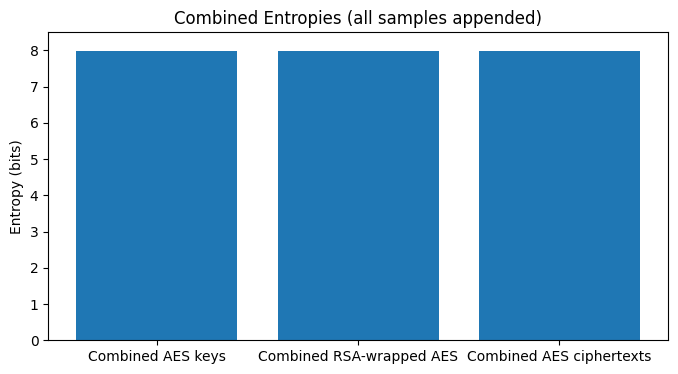

In [ ]:
# ====================================================
# 6️⃣ Visualization (Normalized histograms for fair comparison)
# ====================================================
bins = 25
plt.figure(figsize=(12,5))

# AES key per-sample entropy (density)
plt.subplot(1,3,1)
plt.hist(aes_key_entropies, bins=bins, density=True, alpha=0.8, edgecolor='black')
plt.title("AES Key Entropy (per-sample, normalized)")
plt.xlabel("Entropy (bits)")
plt.ylabel("Density")

# RSA-wrapped AES key entropy (per-sample)
plt.subplot(1,3,2)
plt.hist(rsa_wrapped_entropies, bins=bins, density=True, alpha=0.8, edgecolor='black')
plt.title("RSA-wrapped AES Key Entropy (normalized)")
plt.xlabel("Entropy (bits)")

# AES ciphertext entropy (per-sample)
plt.subplot(1,3,3)
plt.hist(aes_cipher_entropies, bins=bins, density=True, alpha=0.8, edgecolor='black')
plt.title("AES Ciphertext Entropy (normalized)")
plt.xlabel("Entropy (bits)")

plt.tight_layout()
plt.show()

# Ayrıca combined entropileri karşılaştıran çubuk grafik
plt.figure(figsize=(8,4))
ents = [combined_entropy_aes_keys, combined_entropy_wrapped, combined_entropy_aes_cipher]
labels = ["Combined AES keys", "Combined RSA-wrapped AES", "Combined AES ciphertexts"]
plt.bar(labels, ents)
plt.ylabel("Entropy (bits)")
plt.title("Combined Entropies (all samples appended)")
plt.ylim(0, 8.5)
plt.show()


In [ ]:
# ====================================================
# 7️⃣ Results Summary (No CSV Export)
# ====================================================

# 🔹 Her örneğe ait veriler (isteğe bağlı görüntüleme)
per_sample_df = pd.DataFrame({
    "aes_key_entropy": aes_key_entropies,
    "rsa_wrapped_entropy": rsa_wrapped_entropies,
    "aes_cipher_entropy": aes_cipher_entropies,
    "rsa_gen_time_s": times_rsa_keygen,
    "aes_gen_time_s": times_aes_keygen,
    "wrap_time_s": times_wrap,
    "aes_encrypt_time_s": times_aes_encrypt
})

# 🔹 İstersen sadece ilk birkaç satırı göster
print("\n🔹 Örnek 5 satır (per-sample veriler):")
display(per_sample_df.head())

# 🔹 Akademik özet tablo
summary = {
    "Algorithm": "RSA+AES (Hybrid)",
    "RSA Key Length (bits)": rsa_key_length,
    "AES Key Length (bits)": aes_key_length,
    "Number of Samples": num_keys,
    "Mean AES Key Entropy": round(np.mean(aes_key_entropies), 4),
    "Mean Wrapped Entropy": round(np.mean(rsa_wrapped_entropies), 4),
    "Mean Ciphertext Entropy": round(np.mean(aes_cipher_entropies), 4),
    "Mean RSA Gen Time (ms)": round(np.mean(times_rsa_keygen)*1000, 4),
    "Mean AES Gen Time (ms)": round(np.mean(times_aes_keygen)*1000, 4),
    "Mean Wrap Time (ms)": round(np.mean(times_wrap)*1000, 4),
    "Mean AES Encrypt Time (ms)": round(np.mean(times_aes_encrypt)*1000, 4)
}

results_df = pd.DataFrame([summary])

print("\n📊 Summary Table")
display(results_df)



🔹 Örnek 5 satır (per-sample veriler):


,aes_key_entropy,rsa_wrapped_entropy,aes_cipher_entropy,rsa_gen_time_s,aes_gen_time_s,wrap_time_s,aes_encrypt_time_s
0,4.9375,7.155554,6.085229,1.281824,0.000007,0.001528,0.023085
1,5.0000,7.172603,6.175117,1.088126,0.000007,0.001146,0.000529
2,4.8750,7.152996,6.175117,1.202320,0.000008,0.007421,0.000452
3,4.8750,7.260456,6.175117,0.468663,0.000008,0.003113,0.000479
4,4.9375,7.268268,6.138655,4.460055,0.000006,0.001349,0.000437



📊 Summary Table


,Algorithm,RSA Key Length (bits),AES Key Length (bits),Number of Samples,Mean AES Key Entropy,Mean Wrapped Entropy,Mean Ciphertext Entropy,Mean RSA Gen Time (ms),Mean AES Gen Time (ms),Mean Wrap Time (ms),Mean AES Encrypt Time (ms)
0,RSA+AES (Hybrid),2048,256,200,4.8906,7.174,6.1554,581.8954,0.0041,0.7716,0.4357
